In [137]:
import numpy as np
import json
import cv2
from matplotlib import pyplot as plt

def convert_gray_arr_to_gray_image(arr, width, height):
    return cv2.flip(cv2.rotate(arr.reshape(width, height), cv2.ROTATE_90_CLOCKWISE), 1)

def convert_gray_arr_to_image(arr, width, height):
    return cv2.cvtColor(convert_gray_arr_to_gray_image(arr, width, height), cv2.COLOR_GRAY2RGB)


with open("sharpnesses.txt", "r") as f:
    sharpness_gpu_original = np.array(f.read()[1:-1].split(","), dtype=np.float32)

WIDTH = 4756
HEIGHT = 3636



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


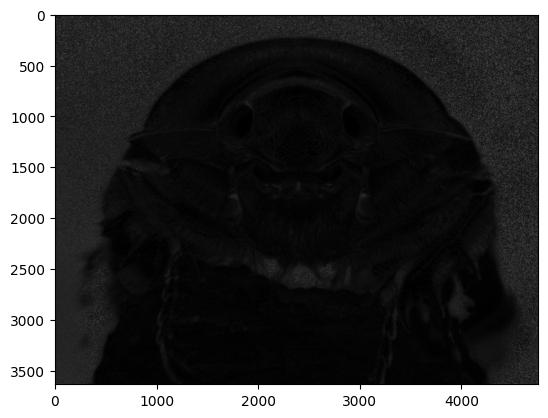

In [138]:
plt.imshow(convert_gray_arr_to_image(sharpness_gpu_original*1e6, WIDTH, HEIGHT))

1446050 41699.5 41699.5
4.76837158203125e-09 5.7220458984375e-08
0.0 223529420000.0


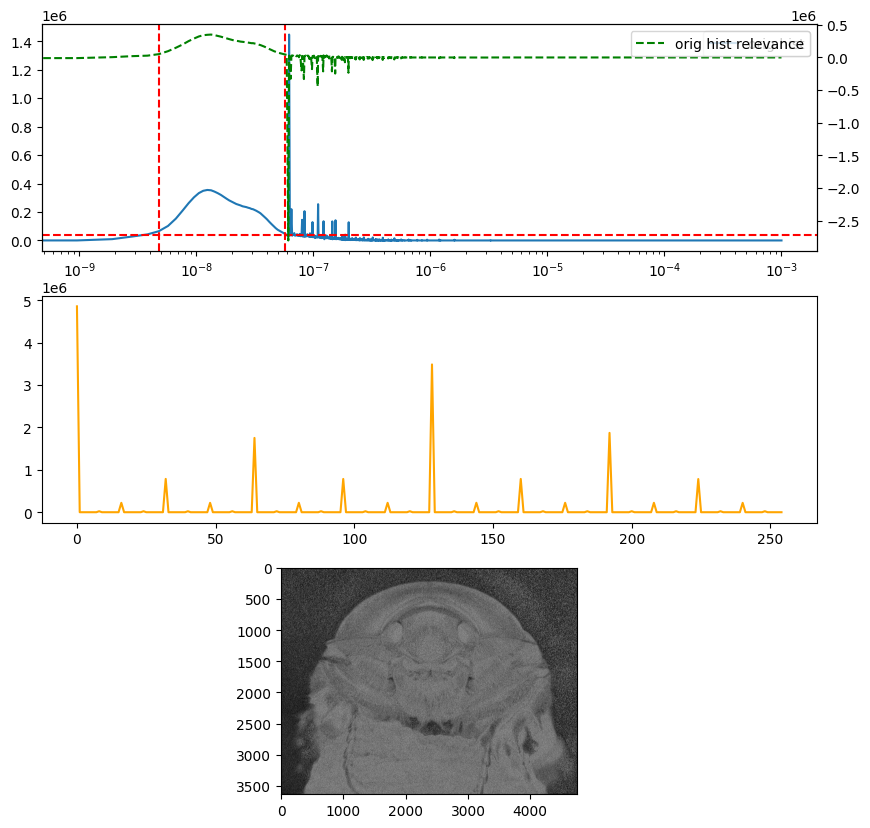

In [230]:
import math

BINS = 4096*256

orig_hist, _ = np.histogram(sharpness_gpu_original, bins=BINS, range=(0,.001))
p = 0.001

orig_hist_at_least_p_percent = orig_hist[orig_hist > WIDTH*HEIGHT*p]
hist_relevance = orig_hist[:-2] - np.abs(np.diff(np.diff(orig_hist)))
orig_hist_max = np.max(orig_hist)
orig_hist_median = np.median(orig_hist_at_least_p_percent)

orig_hist_low_cutoff = orig_hist_median

print(orig_hist_max, orig_hist_median, orig_hist_low_cutoff)
min_val = 0
for i in range(len(orig_hist)-2):
    if hist_relevance[i] > orig_hist_low_cutoff:
        min_val = i
        break
max_val = len(orig_hist) - 1
for i in range(len(orig_hist)-3, -1, -1):
    if hist_relevance[i] > orig_hist_low_cutoff:
        max_val = i
        break

min_val = min_val / BINS * 0.001
max_val = max_val / BINS * 0.001

print(min_val, max_val)
sharpness = sharpness_gpu_original.copy()
sharpness = sharpness * 5.7e13
print(np.min(sharpness), np.max(sharpness))
sharpness_hist, sharpness_hist_scaling = np.histogram((sharpness * 255).astype(np.uint8), bins=255, range=(0,255))

# Corrected scale factor
histo_plot = plt.subplot(3, 1, 1)
histo_plot2 = plt.subplot(3, 1, 2)
image_plot = plt.subplot(3, 1, 3)
image_plot.figure.set_size_inches(10, 10)
image_plot.imshow(convert_gray_arr_to_image((sharpness * 255).astype(np.uint8), WIDTH, HEIGHT))
histo_plot.plot(_[:-3], orig_hist[:-2], label="orig hist")
twin = histo_plot.twinx()
twin.plot(_[:-3], hist_relevance, label="orig hist relevance", color="green", linestyle="--")
histo_plot2.plot(sharpness_hist_scaling[:-1], sharpness_hist, label="sharpness hist", color="orange")
histo_plot.axhline(orig_hist_low_cutoff, color="red", linestyle="--")
histo_plot.axvline(min_val, color="red", linestyle="--")
histo_plot.axvline(max_val, color="red", linestyle="--")
histo_plot.set_xscale("log")
histo_plot.legend()
twin.legend()

